In [6]:
import json
import pandas as pd
import sys
import matplotlib.pyplot as plt

sys.path.append('../../evaluation_utils/')
from plots import upset_plot
from evaluation.evaluation_func import read_results

# Read data

In [7]:
study_list = ['PDC000127', 'PXD030344', 'PXD042844']
path_to_reports = '/home/yuliya/repos/cosybio/FedProt/data/ccRCC_studies/data/'
pg_lists = dict()

for study in study_list:
    print(f"Study: {study}")
    # read csv file
    data_report = pd.read_csv(path_to_reports + study + '/report_filtered.csv', index_col=0)
    print(f"\tNumber of samples in the report: {data_report.shape[0]}")
    print(f"\tNumber of genes in the report: {data_report.shape[1]}")
    # get index and make it a column with "proteins" as a name
    names_df = pd.DataFrame(data_report.index.to_list(), columns=['proteins'])
    # add it to the dictionary
    pg_lists[study] = names_df

Study: PDC000127
	Number of samples in the report: 9964
	Number of genes in the report: 194
Study: PXD030344
	Number of samples in the report: 12548
	Number of genes in the report: 464
Study: PXD042844
	Number of samples in the report: 7655
	Number of genes in the report: 229


In [8]:
# balanced_plot = upset_plot.generate_upset_plot(
#     pg_lists,
#     colname='proteins',
#     title='Upset plot of Genes, ccRCC studies\n',
#     categories=pg_lists.keys(),
#     save_plot=True, 
#     size_fig=(9, 3.5),
#     path_svg='plots/upset_plot_filtered.svg',
# )

/home/yuliya/miniforge3/envs/FedProt/lib/python3.12/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


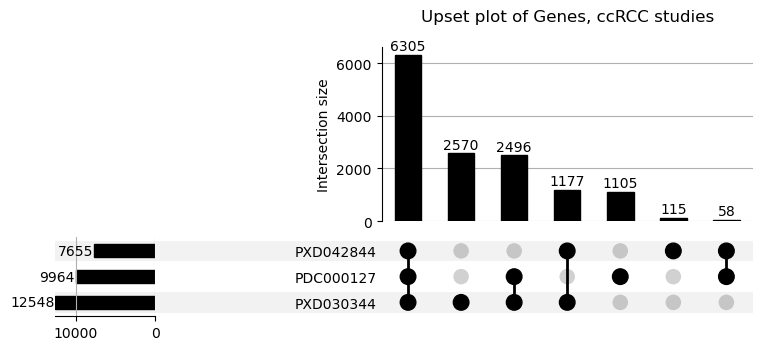

In [9]:
balanced_plot = upset_plot.generate_upset_plot(
    pg_lists,
    colname='proteins',
    title='Upset plot of Genes, ccRCC studies\n',
    categories=pg_lists.keys(),
    save_plot=True, 
    size_fig=(9, 3.5),
    path_svg='plots/upset_plot_all.svg',
)